# Reading in GridRad-Severe Data 

```{image} ../thumbnails/grs_logo.png
:alt: GridRad-Severe Version 4.2 logo
:width: 200px
```

---

## Overview 
For some severe weather events in the Northeast U.S., there has been some observations of severe thunderstorms being locally enhanced by the dynamics of local topography by producing a local enhancement of severe reports or lightning. Past studies such as Wasula et al. (2002), LeBel et al. (2021) and Kramer et al. (2025) have analyzed more specific severe weather events across the central New York region and how some storms were enhanced in severity by processes such as valley channeling and vortex stretching from changes in terrain elevation. In this study, we seek to look at different severe thunderstorm events in the Northeast and study how local topography influences the intensity and distribution of these events. Similar to past studies such as Wasula et al. (2002), we will be looking at various different severe weather outbreaks and compare different synoptic environments and ambient background flows on the topography. Some examples of the differing synoptic-scale setups will be NW vs. SW flow and warm vs. cold season events. One database we will make use of in this research, along with several others, is GridRad-Severe, a gridded radar reflectivity dataset that contains radar data from over 100 stations across the CONUS. 

1. Prerequisites
2. Imports
3. Content
4. Summary
5. Conclusions
6. Resources and References

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Intro to Cartopy](https://foundations.projectpythia.org/core/cartopy/cartopy) | Necessary | |
| [Understanding of Xarray](https://foundations.projectpythia.org/core/xarray/) | Helpful | Analysis of gridded datasets |
| [Understanding of Matplotlib](https://foundations.projectpythia.org/core/matplotlib/) | Helpful | Creating plots in Python |
| [Using Gridradpy Library](https://github.com/tsupinie/gridradpy) | Helpful | Specifically load in and use GridRad data | 
| Project management | Helpful | |

- **Time to learn**: About 50 minutes (10 minutes per subsection)

---

## Imports

Let's first start with importing all the necessary libraries we will need here. We will need cartopy to create maps with specified projections, in conjunction with matplotlib for making plots. We can then import xarray, which is helpful for working with and analyzing gridded datasets such as GridRad-Severe, in addition to the numpy package for scientific computing. 

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

## Content #1: Importing and Plotting a GridRad Radar Reflectivity File

One helpful way to analyze past severe thunderstorms is reading in and plotting a singular GR-S radar file to see how the structure of the storm looked on radar. We can do this by using xarray's open_dataset function to open and decode the NetCDF file. 

In [2]:
file_path = '/nfs/mulholland_lab/acolgate/Research/nexrad_3d_v4_2_20230807T234500Z.nc' # Replace with the path to your file
ds = xr.open_dataset(file_path)

# Inspect the dataset to understand its structure, dimensions, and variables
print(ds)

<xarray.Dataset> Size: 542MB
Dimensions:                    (Sweep: 2114, Altitude: 29, Latitude: 1248,
                                Longitude: 1680, Index: 7007568, time: 1)
Coordinates:
  * Altitude                   (Altitude) float64 232B 0.5 1.0 1.5 ... 21.0 22.0
  * Latitude                   (Latitude) float64 10kB 24.01 24.03 ... 49.99
  * Longitude                  (Longitude) float64 13kB 251.5 251.5 ... 286.5
  * time                       (time) datetime64[ns] 8B 2023-08-07T23:45:00
Dimensions without coordinates: Sweep, Index
Data variables: (12/18)
    sweeps_merged              (Sweep) |S29 61kB ...
    Nradobs                    (Altitude, Latitude, Longitude) int8 61MB ...
    Nradecho                   (Altitude, Latitude, Longitude) int8 61MB ...
    index                      (Index) int32 28MB ...
    Reflectivity               (Index) float32 28MB ...
    wReflectivity              (Index) float32 28MB ...
    ...                         ...
    DifferentialRef

Next, we need to plot the reflecitivity. We do this by decoding the reflectivity grid based on the longitude, latitude and altitude values. We then decode the index since they contain the 1-D grid boxes that contain the radar observations. We can finally build the 3-D reflectivity grid after defining these variables. 

In [44]:
radar_ds = xr.open_dataset('/nfs/mulholland_lab/acolgate/Research/nexrad_3d_v4_2_20230807T234500Z.nc')
#print(radar_ds)

# Decode reflectivity grid (as in your working 2 km slice example)
lon_vals = radar_ds['Longitude'].values
lat_vals = radar_ds['Latitude'].values
alt_vals = radar_ds['Altitude'].values

nlon, nlat, nalt = len(lon_vals), len(lat_vals), len(alt_vals)
reflectivity_grid = np.full((nalt, nlat, nlon), np.nan)

# Decode index
index = radar_ds['index'].values
refl = radar_ds['Reflectivity'].values

k = index // (nlat * nlon)
j = (index % (nlat * nlon)) // nlon
i = index % nlon

reflectivity_grid[k, j, i] = refl

# === Compute Column-Max Reflectivity ===
colmax_refl = np.nanmax(reflectivity_grid, axis=0)  # collapse over altitude
colmax_masked = np.ma.masked_where(np.isnan(colmax_refl) | (colmax_refl < 5), colmax_refl)

# Downsample for speed
step = 1
lons = lon_vals[::step]
lats = lat_vals[::step]
colmax_ds = colmax_masked[::step, ::step]
lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)

Then, let's get to actually plotting this. I mainly used matplotlib functions here to plot the Column-Max Reflectivity, using a smoother type of shading so that the reflectivity looks more higher resolution. We add map features such as states, borders, and coastlines. I then wanted to center the plot over the Turin, NY area, which was the focus around a study by Kramer et al. (2025). The town got hit with a tornadic supercell around 2345Z on August 7th, 2023. We can look the radar reflectivity at that time to analyze the supercell, and also set a lat/lon extent centered over that region to get a clearer view. 

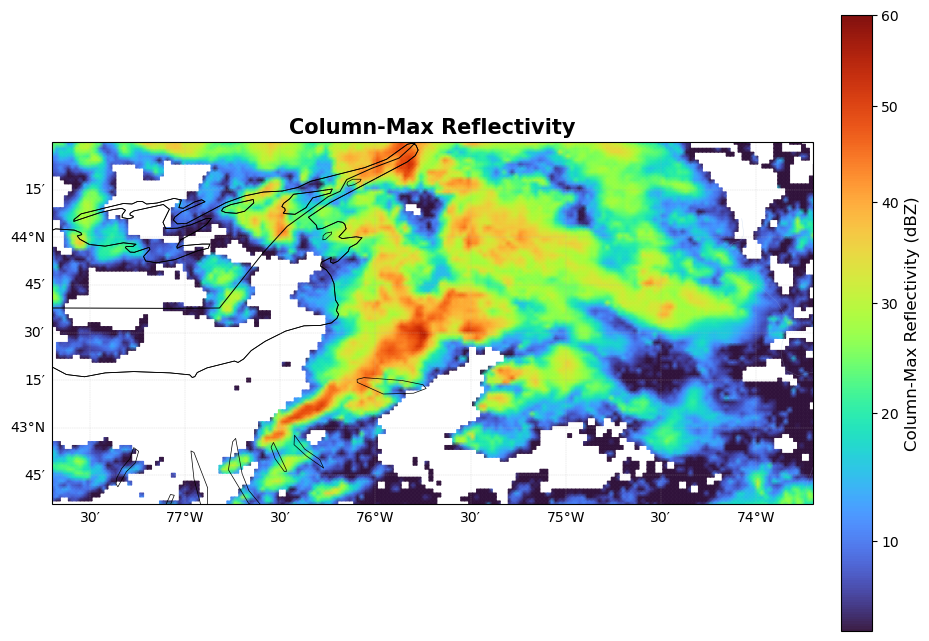

In [68]:
import matplotlib.colors as mcolors

norm = mcolors.PowerNorm(gamma=0.80, vmin=5, vmax=60)

# --- Plot background (Column-Max Reflectivity) ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 8))
pcm = ax.pcolormesh(
    lon_grid, lat_grid, colmax_refl,
    cmap='turbo',
    norm=norm,
    shading='gouraud',
    transform=ccrs.PlateCarree(),
    alpha=0.95
)

cbar = plt.colorbar(pcm, ax=ax, orientation='vertical', shrink=0.8, pad=0.03)
cbar.set_label('Column-Max Reflectivity (dBZ)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

# Map features
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.6)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.7)
ax.add_feature(cfeature.LAKES.with_scale('50m'), edgecolor='black', facecolor='none', linewidth=0.5)
ax.add_feature(cfeature.RIVERS.with_scale('50m'), linewidth=0.3, alpha=0.4)
ax.coastlines(resolution='50m', linewidth=0.7)

extent = [-77.7, -73.7, 42.6, 44.5]

ax.set_extent(extent, crs=ccrs.PlateCarree()) 

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.5, linewidth=0.3, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.set_title('Column-Max Reflectivity', fontsize=15, weight='bold')
plt.tight_layout()
plt.show()

The supercell centered over the Turin, NY area can be seen clearly in the above graph. 

In [41]:
lon_vals = radar_ds['Longitude'].values
lat_vals = radar_ds['Latitude'].values
alt_vals = radar_ds['Altitude'].values

nlon, nlat, nalt = len(lon_vals), len(lat_vals), len(alt_vals)

# Prepare empty 3D array
azshear_grid = np.full((nalt, nlat, nlon), np.nan, dtype=np.float32)

# Decode sparse structure
index = radar_ds['index'].values
azshear = radar_ds['AzShear'].values

# Compute 3D indices
k = index // (nlat * nlon)
j = (index % (nlat * nlon)) // nlon
i = index % nlon

# Fill into full grid
azshear_grid[k, j, i] = azshear

In [42]:
colmax_azshear = np.nanmax(azshear_grid, axis=0)
colmax_azshear = np.squeeze(colmax_azshear)

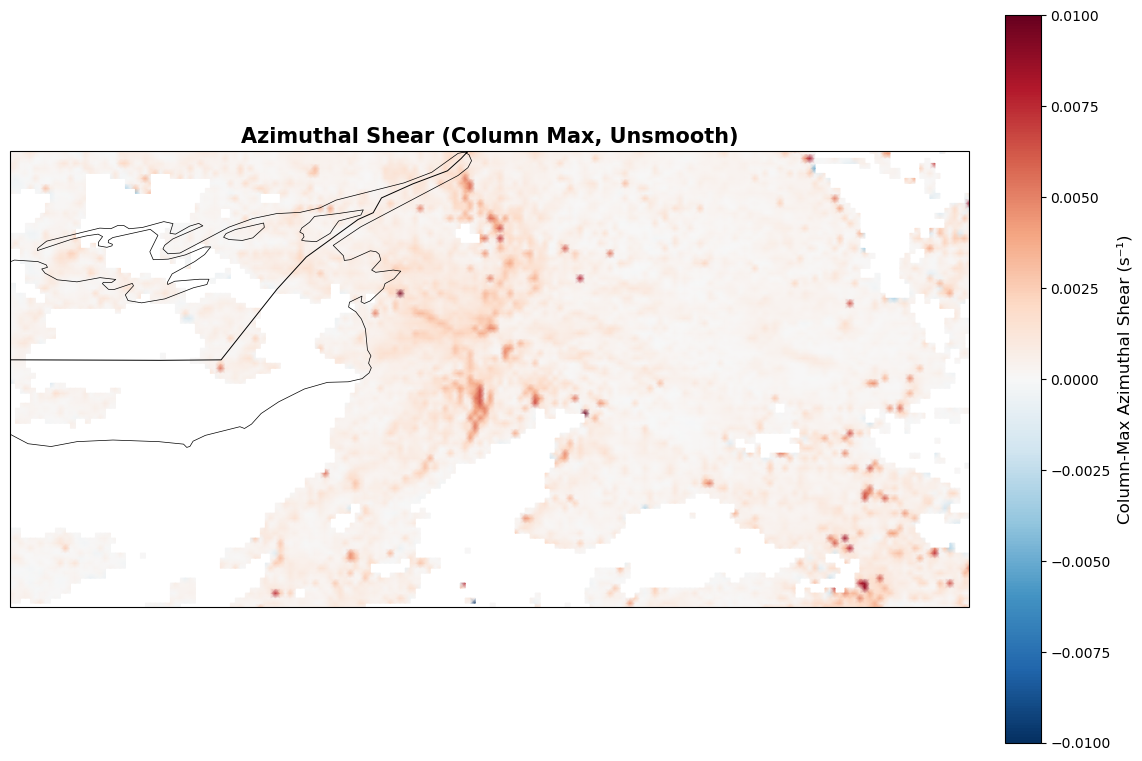

In [43]:
lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 10))

pcm = ax.pcolormesh(
    lon_grid, lat_grid, colmax_azshear,
    cmap='RdBu_r',          # diverging colormap (red=cyclonic, blue=anticyclonic)
    vmin=-0.01, vmax=0.01,  # typical range for MRMS AzShear
    shading='gouraud',      # smooths between pixels, but no data filtering
    transform=ccrs.PlateCarree()
)

# --- Map features ---
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.5)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.7)
ax.coastlines(resolution='50m')

# --- Set zoom region ---
extent = [-77.7, -73.7, 42.6, 44.5]
ax.set_extent(extent, crs=ccrs.PlateCarree())

# --- Colorbar ---
cbar = plt.colorbar(pcm, ax=ax, orientation='vertical', shrink=0.75, pad=0.03)
cbar.set_label("Column-Max Azimuthal Shear (s⁻¹)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

ax.set_title("Azimuthal Shear (Column Max, Unsmooth)", fontsize=15, weight='bold')
plt.tight_layout()
plt.show()

In [38]:
print(colmax_azshear.shape)
print(lat_grid.shape, lon_grid.shape)

()
(1248, 1680) (1248, 1680)


In [40]:
print(radar_ds)

<xarray.Dataset> Size: 542MB
Dimensions:                    (Sweep: 2114, Altitude: 29, Latitude: 1248,
                                Longitude: 1680, Index: 7007568, time: 1)
Coordinates:
  * Altitude                   (Altitude) float64 232B 0.5 1.0 1.5 ... 21.0 22.0
  * Latitude                   (Latitude) float64 10kB 24.01 24.03 ... 49.99
  * Longitude                  (Longitude) float64 13kB 251.5 251.5 ... 286.5
  * time                       (time) datetime64[ns] 8B 2023-08-07T23:45:00
Dimensions without coordinates: Sweep, Index
Data variables: (12/18)
    sweeps_merged              (Sweep) |S29 61kB ...
    Nradobs                    (Altitude, Latitude, Longitude) int8 61MB ...
    Nradecho                   (Altitude, Latitude, Longitude) int8 61MB ...
    index                      (Index) int32 28MB 1249 1257 ... 59900576
    Reflectivity               (Index) float32 28MB 1.5 0.5 1.0 ... 1.5 0.5 4.5
    wReflectivity              (Index) float32 28MB ...
    ...     

In [47]:
print("Reflectivity min/max:", np.nanmin(colmax_refl), np.nanmax(colmax_refl))

Reflectivity min/max: 0.0 70.35867309570312


Reflectivity min/max: 0.0 70.35867309570312


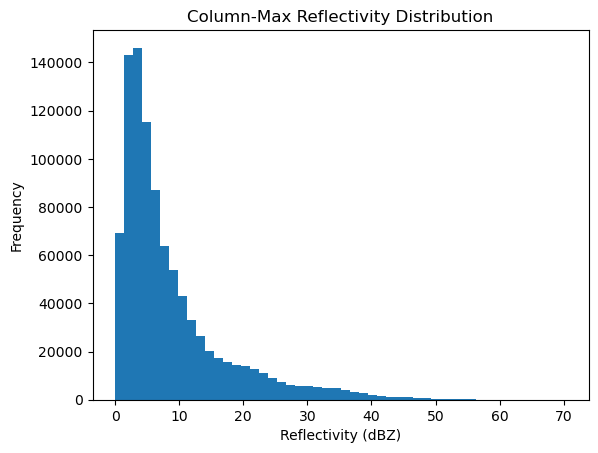

In [49]:
print("Reflectivity min/max:", np.nanmin(colmax_refl), np.nanmax(colmax_refl))
plt.hist(colmax_refl[~np.isnan(colmax_refl)].ravel(), bins=50)
plt.title("Column-Max Reflectivity Distribution")
plt.xlabel("Reflectivity (dBZ)")
plt.ylabel("Frequency")
plt.show()